In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox

from statsmodels.graphics.tsaplots import plot_acf

In [2]:
url = (
    "https://raw.githubusercontent.com/tirthajyoti/Deep-learning-with-Python/"
    "80f337d1584fb123f1a8f7dce0ad190f1a08ce14/"
    "Data/historical-hourly-weather-data/humidity.csv"
)

In [3]:
humidity = pd.read_csv(url)

In [15]:
humidity

,datetime,Vancouver,Portland,San Francisco,Seattle,Los Angeles,San Diego,Las Vegas,Phoenix,Albuquerque,...,Philadelphia,New York,Montreal,Boston,Beersheba,Tel Aviv District,Eilat,Haifa,Nahariyya,Jerusalem
0,2012-10-01 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,25.0,NaN,NaN,NaN
1,2012-10-01 13:00:00,76.0,81.0,88.0,81.0,88.0,82.0,22.0,23.0,50.0,...,71.0,58.0,93.0,68.0,50.0,63.0,22.0,51.0,51.0,50.0
2,2012-10-01 14:00:00,76.0,80.0,87.0,80.0,88.0,81.0,21.0,23.0,49.0,...,70.0,57.0,91.0,68.0,51.0,62.0,22.0,51.0,51.0,50.0
3,2012-10-01 15:00:00,76.0,80.0,86.0,80.0,88.0,81.0,21.0,23.0,49.0,...,70.0,57.0,87.0,68.0,51.0,62.0,22.0,51.0,51.0,50.0
4,2012-10-01 16:00:00,77.0,80.0,85.0,79.0,88.0,81.0,21.0,23.0,49.0,...,69.0,57.0,84.0,68.0,52.0,62.0,22.0,51.0,51.0,50.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45248,2017-11-29 20:00:00,NaN,81.0,NaN,93.0,24.0,72.0,18.0,68.0,37.0,...,27.0,NaN,64.0,37.0,NaN,NaN,NaN,NaN,NaN,NaN
45249,2017-11-29 21:00:00,NaN,71.0,NaN,87.0,21.0,72.0,18.0,73.0,34.0,...,29.0,NaN,59.0,74.0,NaN,NaN,NaN,NaN,NaN,NaN
45250,2017-11-29 22:00:00,NaN,71.0,NaN,93.0,23.0,68.0,17.0,60.0,32.0,...,31.0,NaN,66.0,74.0,NaN,NaN,NaN,NaN,NaN,NaN
45251,2017-11-29 23:00:00,NaN,71.0,NaN,87.0,14.0,63.0,17.0,33.0,30.0,...,26.0,NaN,58.0,56.0,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# humidity.tail() # 2017-11-30 00:00:00

In [9]:
# humidity.head() # 2012-10-01 12:00:00

In [11]:
humidity.columns

Index(['datetime', 'Vancouver', 'Portland', 'San Francisco', 'Seattle',
       'Los Angeles', 'San Diego', 'Las Vegas', 'Phoenix', 'Albuquerque',
       'Denver', 'San Antonio', 'Dallas', 'Houston', 'Kansas City',
       'Minneapolis', 'Saint Louis', 'Chicago', 'Nashville', 'Indianapolis',
       'Atlanta', 'Detroit', 'Jacksonville', 'Charlotte', 'Miami',
       'Pittsburgh', 'Toronto', 'Philadelphia', 'New York', 'Montreal',
       'Boston', 'Beersheba', 'Tel Aviv District', 'Eilat', 'Haifa',
       'Nahariyya', 'Jerusalem'],
      dtype='object')

In [16]:
humidity.shape

(45253, 37)

In [19]:
humidity = pd.read_csv(url, index_col='datetime', parse_dates=['datetime'])

In [22]:
humidity_eilat = humidity["Eilat"]

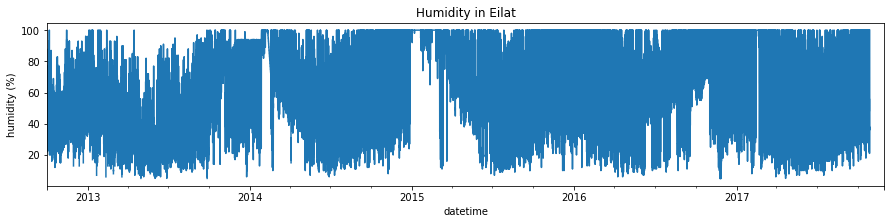

In [25]:
humidity_eilat.plot(figsize=(15,3))
plt.title('Humidity in Eilat')
plt.ylabel('humidity (%)')
plt.show()

In [26]:
humidity_eilat.isna().sum()

970

In [29]:
humidity_eilat

datetime
2012-10-01 12:00:00    25.0
2012-10-01 13:00:00    22.0
2012-10-01 14:00:00    22.0
2012-10-01 15:00:00    22.0
2012-10-01 16:00:00    22.0
                       ... 
2017-11-29 20:00:00     NaN
2017-11-29 21:00:00     NaN
2017-11-29 22:00:00     NaN
2017-11-29 23:00:00     NaN
2017-11-30 00:00:00     NaN
Name: Eilat, Length: 45253, dtype: float64

In [34]:
humidity_eilat = humidity_eilat.ffill()
humidity_eilat.isna().sum()

0

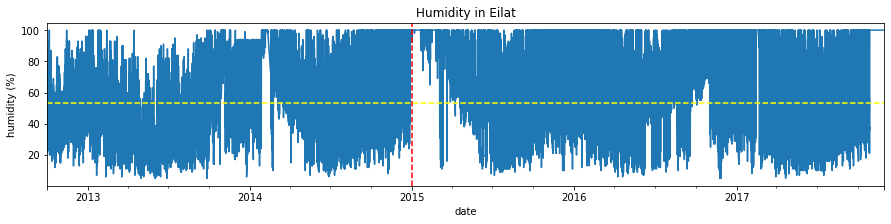

In [41]:
ax = humidity_eilat.plot(figsize=(15,3))
ax.set_title('Humidity in Eilat')
ax.set_xlabel('date')
ax.set_ylabel('humidity (%)')
ax.axvline('2015-01-01', color='red', linestyle='--')
ax.axhline(humidity_portland.mean(), color='yellow', linestyle='--')
plt.show()

In [45]:
humidity_eilat.asfreq('D', method='bfill').head() # позволяет просто посмотреть данные по дням

datetime
2012-10-01 12:00:00    25.0
2012-10-02 12:00:00    29.0
2012-10-03 12:00:00    29.0
2012-10-04 12:00:00    34.0
2012-10-05 12:00:00    24.0
Freq: D, Name: Eilat, dtype: float64

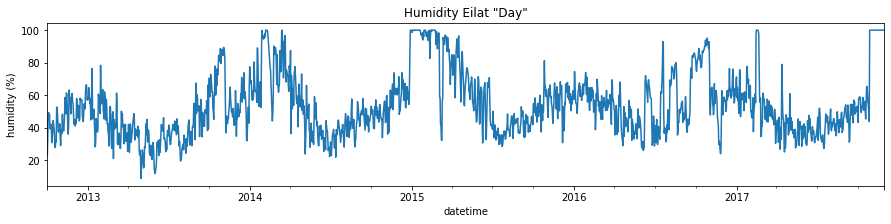

In [62]:
# Если мы хоти уже сделать каике-то манипуляции с данными, то приходит 
# на помощь метод .resample
humidity_eilat_day = humidity_eilat.resample("D").mean()
humidity_eilat_day.plot(figsize=(15,3))
plt.title('Humidity Eilat "Day"')
plt.ylabel("humidity (%)")
plt.show()

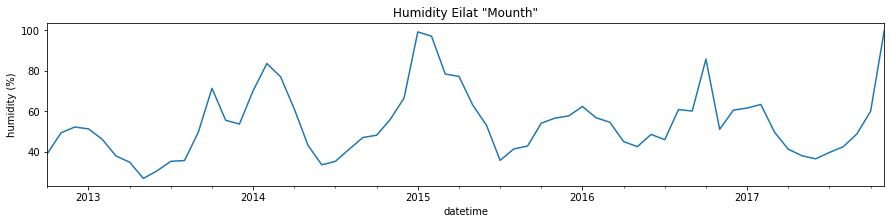

In [63]:
# Если мы хоти уже сделать каике-то манипуляции с данными, то приходит 
# на помощь метод .resample
humidity_eilat_mounth = humidity_eilat.resample("M").mean()
humidity_eilat_mounth.plot(figsize=(15,3))
plt.title('Humidity Eilat "Mounth"')
plt.ylabel("humidity (%)")
plt.show()

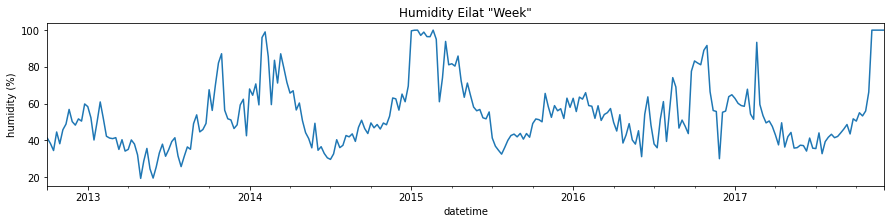

In [64]:
# Если мы хоти уже сделать каике-то манипуляции с данными, то приходит 
# на помощь метод .resample
humidity_eilat_week = humidity_eilat.resample("W").mean()
humidity_eilat_week.plot(figsize=(15,3))
plt.title('Humidity Eilat "Week"')
plt.ylabel("humidity (%)")
plt.show()

<AxesSubplot:xlabel='datetime'>

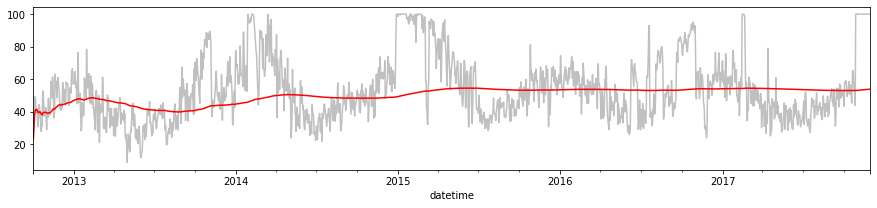

In [65]:
humidity_eilat_expanding_day = humidity_eilat_day.expanding().mean()
humidity_eilat_day.plot(c='silver', figsize=(15,3))
humidity_eilat_expanding_day.plot(c='r')

<AxesSubplot:xlabel='datetime'>

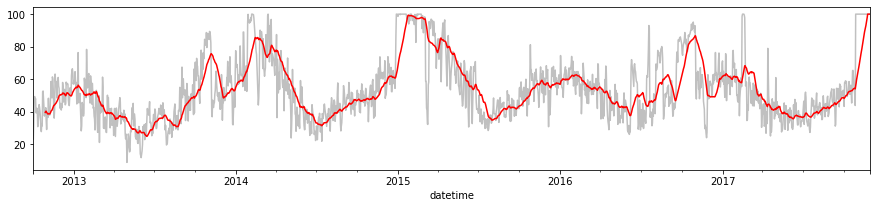

In [66]:
humidity_eilat_sliding_day = humidity_eilat_day.rolling(window=28).mean()

humidity_eilat_day.plot(c='silver', figsize=(15,3))
humidity_eilat_sliding_day.plot(c="r")

In [67]:
complete_years = [
    year for year, values in humidity_eilat_day.groupby(humidity_eilat_day.index.year)
    if len(values) == pd.Timestamp(year=year, month=12, day=31).dayofyear
]
print('полные годы:', complete_years)

полные годы: [2013, 2014, 2015, 2016]


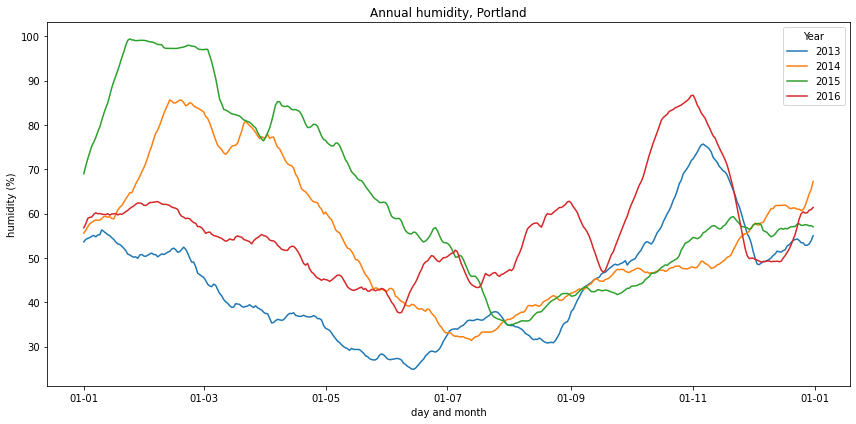

In [70]:
plt.figure(figsize=(12, 6))
for year in complete_years:
    yearly_data = humidity_eilat_sliding_day[humidity_eilat_sliding_day.index.year == year]
    plot_date = pd.to_datetime(yearly_data.index.strftime('2000-%m-%d'))
    plt.plot(plot_date, yearly_data, label=str(year))
    
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%d-%m'))
plt.xlabel('day and month')
plt.ylabel('humidity (%)')
plt.title('Annual humidity, Portland')
plt.legend(title='Year')
plt.tight_layout()
plt.show()

In [85]:
monthly = humidity_eilat_day.resample('MS').mean().to_frame(name='Eilat')
monthly['MoM'] = monthly['Eilat'].pct_change() * 100

yearly = humidity_eilat_day.resample('YS').mean().to_frame(name='Eilat')
yearly['YoY'] = yearly['Eilat'].pct_change() * 100
print(monthly.head(15))
print("")
print("---")
print("")
print(yearly.head(15))

                Eilat        MoM
datetime                        
2012-10-01  39.188172        NaN
2012-11-01  49.412500  26.090342
2012-12-01  52.260753   5.764235
2013-01-01  51.357527  -1.728306
2013-02-01  46.223214  -9.997196
2013-03-01  38.030914 -17.723346
2013-04-01  34.933333  -8.144902
2013-05-01  26.967742 -22.802265
2013-06-01  30.697222  13.829413
2013-07-01  35.381720  15.260333
2013-08-01  35.755376   1.056071
2013-09-01  49.641667  38.836930
2013-10-01  71.323925  43.677538
2013-11-01  55.597222 -22.049687
2013-12-01  53.732527  -3.353936

---

                Eilat        YoY
datetime                        
2012-01-01  46.927083        NaN
2013-01-01  44.135274  -5.949250
2014-01-01  55.120890  24.890786
2015-01-01  62.855137  14.031425
2016-01-01  56.272427 -10.472827
2017-01-01  52.764346  -6.234103


In [91]:
monthly['year'] = monthly.index.year
monthly['month'] = monthly.index.month

In [95]:
yearly['year'] = yearly.index.year
yearly['month'] = yearly.index.month

In [94]:
pivot = monthly.pivot_table(index='year', columns='month', values='MoM')
pivot

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26.090342,5.764235
2013,-1.728306,-9.997196,-17.723346,-8.144902,-22.802265,13.829413,15.260333,1.056071,38.836930,43.677538,-22.049687,-3.353936
2014,30.592591,19.044313,-7.781989,-20.653313,-29.263736,-22.194831,5.128714,16.973244,13.875495,2.372135,16.301839,18.706131
2015,48.880589,-2.113907,-19.228731,-1.478185,-18.245103,-15.687569,-32.669708,15.775852,3.386896,26.273668,4.623173,1.911765
2016,8.027277,-8.941595,-3.851338,-17.469629,-5.491902,14.147211,-5.334701,32.221898,-1.186901,42.543325,-40.343492,18.494186
2017,1.674429,2.855974,-21.591492,-16.811818,-7.813355,-3.919024,8.546111,7.013628,14.918945,22.801180,66.599489,NaN


In [96]:
pivot = yearly.pivot_table(index='year', columns='month', values='YoY')
pivot

month,1
year,
2013,-5.949250
2014,24.890786
2015,14.031425
2016,-10.472827
2017,-6.234103


In [99]:
eilat_lags = humidity_eilat_day.to_frame(name="Eilat")
eilat_lags['lag_1'] = eilat_lags['Eilat'].shift(1)
eilat_lags['lead_1'] = eilat_lags['Eilat'].shift(-1)
eilat_lags.head()

,Eilat,lag_1,lead_1
datetime,,,
2012-10-01,23.250000,NaN,33.833333
2012-10-02,33.833333,23.250000,47.291667
2012-10-03,47.291667,33.833333,49.333333
2012-10-04,49.333333,47.291667,46.875000
2012-10-05,46.875000,49.333333,48.083333


In [160]:
y = humidity_eilat_day

In [103]:
variance = np.var(y)
print("Дисперсия:", variance)
print("Ст.отклонение:", np.sqrt(variance))

Дисперсия: 372.79521671130163
Ст.отклонение: 19.30790554957481


In [105]:
def auto_covariance(y, lag=0):
    x = np.asarray(y, dtype=float)
    x_centered = x - x.mean()

    # Одинаковый знаменатель для всех лагов нужен для расчёта ACF.
    return np.sum(x_centered[lag:] * x_centered[:len(x) - lag]) / len(x)

In [166]:
from statsmodels.tsa.stattools import acovf
acovf(y)[-1]          # fft=False — точный расчёт без БПФ

-0.7487787411903957

In [107]:
lag1_cov = auto_covariance(y, lag=1)
print(lag1_cov)

lag2_cov = auto_covariance(y, lag=2)
print(lag2_cov)

lag3_cov = auto_covariance(y, lag=3)
print(lag3_cov)

339.5737384307656
315.18330691444015
298.95764311528865


In [108]:
def adf_test(timeseries):
    print("Results of Dickey-Fuller Test:")
    # обратите внимание на regression="c"
    # - это как раз проверка стационарности вокруг константы
    dftest = adfuller(timeseries, regression="c", autolag="AIC")
    dfoutput = pd.Series(
        dftest[0:4],
        index=[
            "Test Statistic",
            "p-value",
            "#Lags Used",
            "Number of Observations Used",
        ],
    )
    for key, value in dftest[4].items():
        dfoutput["Critical Value (%s)" % key] = value
    print(dfoutput)

In [109]:
adf_test(humidity_eilat_day)

Results of Dickey-Fuller Test:
Test Statistic                   -3.419634
p-value                           0.010307
#Lags Used                       15.000000
Number of Observations Used    1871.000000
Critical Value (1%)              -3.433850
Critical Value (5%)              -2.863086
Critical Value (10%)             -2.567593
dtype: float64


In [116]:
def kpss_test(timeseries):
    print("Results of KPSS Test:")
    # обратите внимание на regression="c"
    # - это как раз проверка стационарности вокруг константы
    kpsstest = kpss(timeseries, regression="c", nlags="auto")
    kpss_output = pd.Series(
        kpsstest[0:3], index=["Test Statistic", "p-value", "Lags Used"]
    )
    for key, value in kpsstest[3].items():
        kpss_output["Critical Value (%s)" % key] = value
    print(kpss_output)

In [117]:
kpss(humidity_eilat_day)

(0.36639873258031275,
 0.09163847733607208,
 26,
 {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})

In [118]:
# ADF: p ≤ 0.05 → стационарен.
# KPSS: p > 0.05 → стационарен.

In [122]:
def variance_for_acf(y):
    return auto_covariance(y, lag=0)

def auto_correlation(y, lag=1):
    return auto_covariance(y, lag) / variance_for_acf(y)

In [141]:
lag1_autocorr = auto_correlation(humidity_eilat_day, lag=1)  # автокорреляция с лагом
print(lag1_autocorr)

lag2_autocorr = auto_correlation(humidity_eilat_day, lag=105)
print(lag2_autocorr)

lag7_autocorr = auto_correlation(humidity_eilat_day, lag=150)
print(lag7_autocorr)

lag365_autocorr = auto_correlation(humidity_eilat_day, lag=400)
print(lag365_autocorr)

0.9108854491921651
0.001639698169136729
-0.22328211931811867
0.2240025187336335


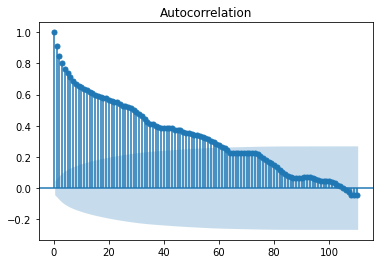

In [130]:
plot_acf(y, lags=110)
plt.show()

In [144]:
acorr_ljungbox(humidity_eilat_day, return_df=True, lags=365)

,lb_stat,lb_pvalue
1,1568.157570,0.0
2,2919.851167,0.0
3,4136.601907,0.0
4,5246.011120,0.0
5,6276.731735,0.0
...,...,...
361,54430.643464,0.0
362,54506.935527,0.0
363,54589.675194,0.0
364,54677.359979,0.0


In [145]:
# => автокоррелирован
# p-значение > уровня значимости (по умолчанию: 0.05): Не удается отклонить нулевую гипотезу H(0), временной ряд не автокоррелирован.
# p-значение <= уровня значимости (по умолчанию: 0.05): Отклоняем нулевую гипотезу H(0), временной ряд автокоррелирован.

# Вывод: как читать меры и тесты

## Автоковариация
Считает сырую связь \(y_t\) и \(y_{t-k}\): насколько они вместе отклоняются от среднего.  
Это не тест, а мера.
- заметно > 0 → ряд помнит прошлое на этом лаге
- ≈ 0 → связи нет
- зависит от масштаба ряда (сотни/тысячи нормальны, если сам ряд в тех же единицах)

## Автокорреляция (ACF)
Та же связь, но делённая на дисперсию. Всегда от −1 до 1. Не тест, а мера.

\(\rho_k = \mathrm{cov}(y_t, y_{t-k}) / \mathrm{var}(y_t)\)

- 0.9 → очень сильная связь (сегодня ≈ вчера)
- 0.2 → слабая
- ≈ 0 → нет связи
- < 0 → «отскок» (высокое k шагов назад → низкое сейчас)
- на `plot_acf`: столбик за пунктиром → связь значима
- медленно тает → тренд / блуждание
- горб каждые 7 / 12 / 24 / 365 → сезон

## ADF
Ищет единичный корень: ряд блуждает и сам к среднему не возвращается.

- **H₀:** нестационарный (есть единичный корень)
- **H₁:** стационарный
- p ≤ 0.05 → отвергаем H₀ → стационарен
- p > 0.05 → не отвергаем H₀ → нестационарен, смотри `diff()`

Сезон и гуляющую дисперсию сам по себе не ловит.

## KPSS
Проверяет стационарность с другой стороны (стохастический тренд).  
Гипотезы **перевёрнуты** относительно ADF.

- **H₀:** стационарный
- **H₁:** нестационарный
- p > 0.05 → не отвергаем H₀ → стационарен
- p ≤ 0.05 → отвергаем H₀ → нестационарен, смотри `diff()`

В ADF маленький p «хорош» для стационарности.  
В KPSS большой p «хорош» для стационарности.

## ADF + KPSS вместе
| ADF | KPSS | Вывод |
|---|---|---|
| p ≤ 0.05 | p > 0.05 | скорее стационарный |
| p > 0.05 | p ≤ 0.05 | скорее нестационарный → `diff()` |
| оба так или оба эдак | | вердикта нет, смотри график |

## Ljung-Box
Проверяет пачку лагов: есть ли автокорреляция в первых m шагах.

- **H₀:** автокорреляции нет (белый шум)
- **H₁:** автокорреляция есть
- p ≤ 0.05 → память есть
- p > 0.05 → белый шум

На сыром ряде p ≈ 0 часто нормален.  
На остатках модели: p > 0.05 → модель вытащила структуру; p ≤ 0.05 → модель можно улучшить.  
Дни: 7 / 14 / 30. Часы: 24 / 48. Месяцы: 12 / 24.

## Коротко
1. ACF — насколько помнит.  
2. ADF + KPSS — блуждает ли уровень.  
3. Ljung-Box — есть ли память (ряд или остатки).  
4. Стационарный ≠ белый шум.  
5. Сначала график, потом тесты.